# Clustering

This notebook performs K-Means clustering on Italian municipalities
based on their road accident concentration metrics.
The goal is to segment municipalities into groups with similar accident profiles
to support business investment decisions.

In [8]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import sys
sys.path.append('../config')
from config import *

In [9]:
# import df_merged_istat_data_comuni_name 
df_merged_istat_data_comuni_name = pd.read_csv(CLEAN_PATH + 'cleaned_istat_data.csv')

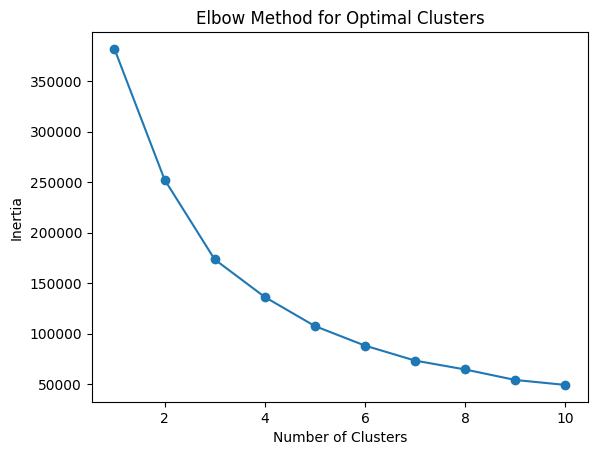

In [10]:
# scale the ROADACC_PER_CAPITA and ROADACC_PER_KM2 columns using StandardScaler because they have different scales and we want to give them equal importance in the clustering algorithm
scaler = StandardScaler()
X = df_merged_istat_data_comuni_name[['ROADACC_PER_CAPITA', 'ROADACC_PER_KM2']]
X_scaled = scaler.fit_transform(X)

# use the elbow method to find the optimal number of clusters for KMeans clustering
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot the inertia values to visualize the elbow point
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

## Choosing the Optimal Number of Clusters

The elbow plot shows a clear change in slope around k=3.
After k=3 the inertia decreases much more slowly, indicating that additional clusters
do not add significant value. We therefore choose k=3 for our model.

In [11]:
# add the scaled columns to the dataframe to use them for plotting
# this allows us to visualize the clusters in the standardized space
# where the KMeans algorithm was trained
df_merged_istat_data_comuni_name["ROADACC_PER_CAPITA_scaled"] = X_scaled[:, 0]
df_merged_istat_data_comuni_name["ROADACC_PER_KM2_scaled"] = X_scaled[:, 1]

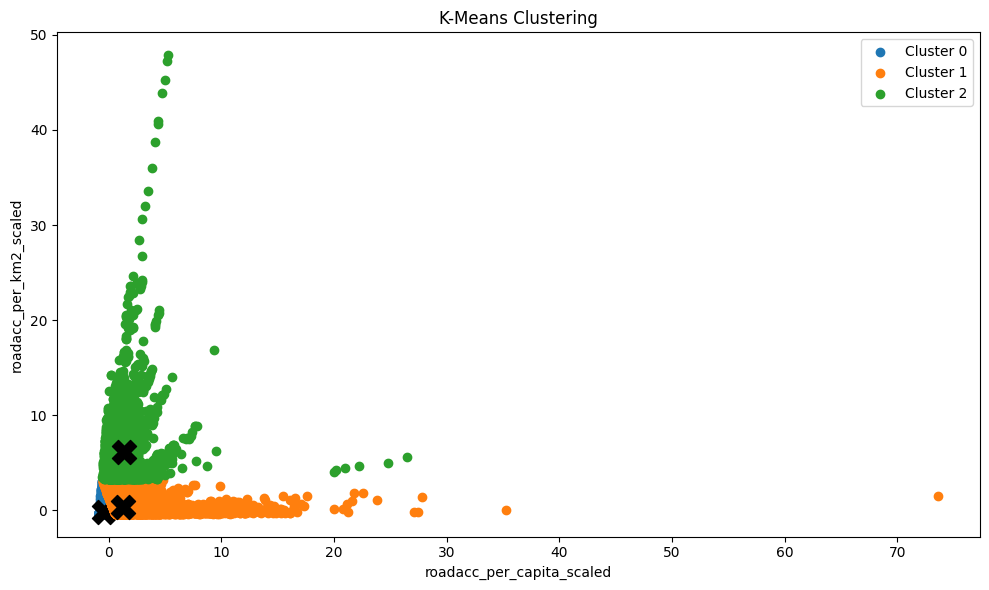

In [12]:
# Instantiate and fit the KMeans model

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Add the cluster labels to the DataFrame
df_merged_istat_data_comuni_name["cluster"] = kmeans.labels_

# Plot the clusters and centroids
centroids = kmeans.cluster_centers_
clusters = df_merged_istat_data_comuni_name.groupby("cluster")

plt.figure(figsize=(10, 6))
for cluster, data in clusters:
    plt.scatter(data["ROADACC_PER_CAPITA_scaled"], data["ROADACC_PER_KM2_scaled"], marker="o", label=f'Cluster {cluster}')
    plt.scatter(centroids[cluster, 0], centroids[cluster, 1], marker="X", color="black", s=300)

plt.xlabel("roadacc_per_capita_scaled")
plt.ylabel("roadacc_per_km2_scaled")
plt.title("K-Means Clustering")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# create a new column in the DataFrame to store the cluster labels as strings for better readability
cluster_labels = {
    0: 'Low Risk',
    1: 'High Per Capita',
    2: 'High Per Km2'
}
df_merged_istat_data_comuni_name["cluster_label"] = df_merged_istat_data_comuni_name["cluster"].map(cluster_labels)

# display the value counts of each cluster label to see how many municipalities fall into each risk category
df_merged_istat_data_comuni_name['cluster_label'].value_counts()

# save the DataFrame with cluster labels to a new CSV file for further analysis or reporting
df_merged_istat_data_comuni_name.to_csv(CLEAN_PATH + 'clustered_istat_data.csv', index=False)